# ResNet18 po kategorijama

In [1]:
import os 
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.metrics import accuracy_score
import statistics

### Dataset i DataLoader

In [2]:
dataset = 'dataset_224x224'

class MVTecDataset(Dataset):
    def __init__(self, putanja_dataseta, kategorija, transformacija=None, mod="train"):
        super().__init__()
        self.transformacija = transformacija
        self.podaci = []

        if mod == "train":
            good_putanja = os.path.join(putanja_dataseta, kategorija, "train", "good")
            for naziv_slike in os.listdir(good_putanja):
                self.podaci.append((os.path.join(good_putanja, naziv_slike), 0))

            test_putanja = os.path.join(putanja_dataseta, kategorija, "test")
            for podfolder in os.listdir(test_putanja):
                if podfolder != "good":
                    puna_putanja = os.path.join(test_putanja, podfolder)
                    slike=os.listdir(puna_putanja)
                    train_deo = int(len(slike) * 0.7)
                    for naziv_slike in slike[:train_deo]:
                        self.podaci.append((os.path.join(puna_putanja, naziv_slike), 1))

        elif mod == "test":
            test_putanja = os.path.join(putanja_dataseta, kategorija, "test")
            for podfolder in os.listdir(test_putanja):
                puna_putanja = os.path.join(test_putanja, podfolder)
                slike=os.listdir(puna_putanja)
                if podfolder == "good":
                    for naziv_slike in slike:
                        self.podaci.append((os.path.join(puna_putanja, naziv_slike), 0))
                else:
                    test_deo = int(len(slike) * 0.7)
                    for naziv_slike in slike[test_deo:]:
                        self.podaci.append((os.path.join(puna_putanja, naziv_slike), 1))

        np.random.shuffle(self.podaci)

    def __len__(self):
        return len(self.podaci)
    
    def __getitem__(self, indeks):
        putanja, labela = self.podaci[indeks]
        slika = Image.open(putanja).convert("RGB")
        if self.transformacija:
            slika = self.transformacija(slika)
        return slika, labela

### Treniranje po kategorijama

In [5]:
transformacija = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

uredjaj = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(uredjaj)
print(torch.cuda.get_device_name(0))

kategorije = sorted([k for k in os.listdir(dataset) if os.path.isdir(os.path.join(dataset, k))])

rezultati = {}
broj_epoha = 20

os.makedirs("modeli/po_kategoriji", exist_ok=True)

for kategorija in kategorije:
    print(f"\n---Treniranje: {kategorija} ---")

    train_dataset = MVTecDataset(dataset, kategorija, transformacija=transformacija, mod="train")
    test_dataset = MVTecDataset(dataset, kategorija, transformacija=transformacija, mod="test")
    
    labele = [l for _, l in train_dataset.podaci]
    if labele.count(1) == 0:
        print(f" Nema defektnih slika za {kategorija}")
        continue

    tezine = torch.DoubleTensor([1.0/labele.count(0) if l == 0 else 1.0/labele.count(1) for l in labele])
    sampler = WeightedRandomSampler(tezine, num_samples=len(tezine), replacement=True)

    train_dataloader = DataLoader(train_dataset, batch_size=128, sampler=sampler)
    test_dataloader = DataLoader(test_dataset, batch_size=128, shuffle=False)
    
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, 2)
    model = model.to(uredjaj)

    kriterijum = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0001)

    for epoha in range(broj_epoha):
        model.train()
        ukupan_loss = 0
        for slike, labele_batch in train_dataloader:
            slike = slike.to(uredjaj)
            labele_batch = labele_batch.to(uredjaj)
            optimizer.zero_grad()
            izlaz = model(slike)
            loss = kriterijum(izlaz, labele_batch)
            loss.backward()
            optimizer.step()
            ukupan_loss += loss.item()
        print(f" Epoha [{epoha+1}/{broj_epoha}] | Loss: {ukupan_loss/len(train_dataloader):.4f}")

    model.eval()
    sve_pred = []
    sve_lab = []
    with torch.no_grad():
        for slike, labele_batch in test_dataloader:
            slike = slike.to(uredjaj)
            izlaz = model(slike)
            predikcije = izlaz.argmax(axis=1)
            sve_pred.extend(predikcije.cpu().numpy())
            sve_lab.extend(labele_batch.numpy())

    tacnost = accuracy_score(sve_lab, sve_pred) * 100
    rezultati[kategorija] = tacnost
    print(f" Tacnost {kategorija}: {tacnost:.2f}%")

    torch.save(model.state_dict(), f"modeli/po_kategoriji/{kategorija}_model.pth")

cuda
NVIDIA GeForce RTX 3060 Ti

---Treniranje: bottle ---
 Epoha [1/20] | Loss: 0.4409
 Epoha [2/20] | Loss: 0.0858
 Epoha [3/20] | Loss: 0.0344
 Epoha [4/20] | Loss: 0.0111
 Epoha [5/20] | Loss: 0.0039
 Epoha [6/20] | Loss: 0.0021
 Epoha [7/20] | Loss: 0.0013
 Epoha [8/20] | Loss: 0.0015
 Epoha [9/20] | Loss: 0.0012
 Epoha [10/20] | Loss: 0.0006
 Epoha [11/20] | Loss: 0.0011
 Epoha [12/20] | Loss: 0.0006
 Epoha [13/20] | Loss: 0.0004
 Epoha [14/20] | Loss: 0.0003
 Epoha [15/20] | Loss: 0.0003
 Epoha [16/20] | Loss: 0.0007
 Epoha [17/20] | Loss: 0.0003
 Epoha [18/20] | Loss: 0.0002
 Epoha [19/20] | Loss: 0.0002
 Epoha [20/20] | Loss: 0.0002
 Tacnost bottle: 92.50%

---Treniranje: cable ---
 Epoha [1/20] | Loss: 0.5023
 Epoha [2/20] | Loss: 0.1532
 Epoha [3/20] | Loss: 0.0629
 Epoha [4/20] | Loss: 0.0316
 Epoha [5/20] | Loss: 0.0141
 Epoha [6/20] | Loss: 0.0053
 Epoha [7/20] | Loss: 0.0027
 Epoha [8/20] | Loss: 0.0038
 Epoha [9/20] | Loss: 0.0019
 Epoha [10/20] | Loss: 0.0022
 Epoha [1

### Prikaz rezulatata

Kategorija      | Tacnost 
------------------------------
bottle          | 92.50%
cable           | 93.18%
capsule         | 82.46%
carpet          | 51.72%
grid            | 68.29%
hazelnut        | 96.88%
leather         | 48.39%
metal_nut       | 96.08%
pill            | 83.33%
screw           | 82.28%
tile            | 95.08%
toothbrush      | 61.90%
transistor      | 83.33%
wood            | 84.62%
zipper          | 94.37%
------------------------------
Srednja tacnost | 80.96%
Medijana        | 83.33%


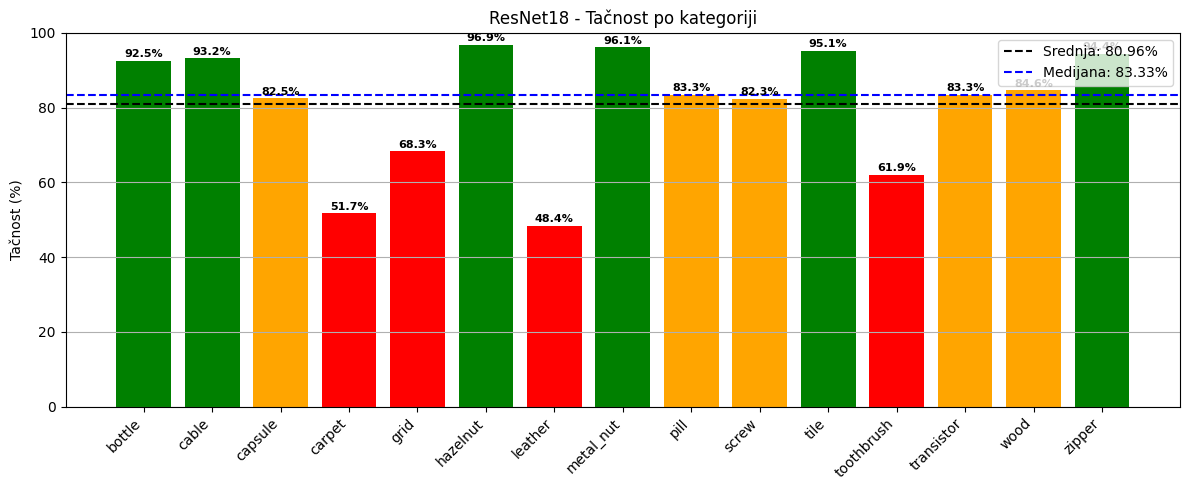

In [6]:
kategorije_lista = list(rezultati.keys())
tacnosti_lista = list(rezultati.values())
srednja_tacnost = np.mean(tacnosti_lista)
medijana_tacnost = statistics.median(tacnosti_lista)

print(f"{'Kategorija':15} | {'Tacnost':8}")
print("-" * 30)
for kat, tac in rezultati.items():
    print(f"{kat:15} | {tac:.2f}%")
print("-" * 30)
print(f"{'Srednja tacnost':15} | {srednja_tacnost:.2f}%")
print(f"{'Medijana':15} | {medijana_tacnost:.2f}%")

plt.figure(figsize=(12, 5))
boje = ['green' if t >= 90 else 'orange' if t >= 75 else 'red' for t in tacnosti_lista]
plt.bar(kategorije_lista, tacnosti_lista, color=boje)
plt.axhline(srednja_tacnost, color='black', linestyle='--', label=f'Srednja: {srednja_tacnost:.2f}%')
plt.axhline(medijana_tacnost, color='blue', linestyle='--', label=f'Medijana: {medijana_tacnost:.2f}%')
plt.xticks(rotation=45, ha='right')
plt.title('ResNet18 - Tačnost po kategoriji')
plt.ylabel('Tačnost (%)')
plt.ylim(0, 100)
for i, v in enumerate(tacnosti_lista):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=8, fontweight='bold')
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()